### Dataset preparation    
#### Convert water vector to raster image (for l5,l7,l8, l9). 


In [2]:
import numpy as np
from glob import glob
import rasterio as rio 
import geopandas as gpd
import cartopy.crs as ccrs
from pyrsimg import imgShow
from rasterio import features
import matplotlib.pyplot as plt
from shapely.geometry import Point
import cartopy.feature as cfeature 
from notebooks import config 


In [16]:
dir_truth_gpkg = 'data/dset/truth/truth_gpkg/'
dir_truth_tif = 'data/dset/truth/truth_tif/'
dir_scene = 'data/dset/scene/scene_ori/'
### get the secene and truth pairwise data
paths_scene = sorted(glob(dir_scene+'*/*.tif'))
paths_scene = [path for path in paths_scene if 's2' not in path] 
paths_truth = sorted(glob(dir_truth_gpkg+'*/*.gpkg'))
print(len(paths_scene))
print(len(paths_truth)) 
print(paths_scene[77])
print(paths_truth[77]) 


119
119
data/dset/scene/scene_ori/l8/l8_scene_19.tif
data/dset/truth/truth_gpkg/l8/l8_scene_19_truth_final.gpkg


In [18]:
## check the pair-wise scene images and the truth vector
id_dset = 77
scene_rio = rio.open(paths_scene[id_dset])
truth_vec_gpd = gpd.read_file(paths_truth[id_dset])
scene_extent = [scene_rio.bounds.left, scene_rio.bounds.right, 
                scene_rio.bounds.bottom, scene_rio.bounds.top]
print(paths_scene[id_dset])
print(paths_truth[id_dset]) 


data/dset/scene/scene_ori/l8/l8_scene_19.tif
data/dset/truth/truth_gpkg/l8/l8_scene_19_truth_final.gpkg


<Axes: >

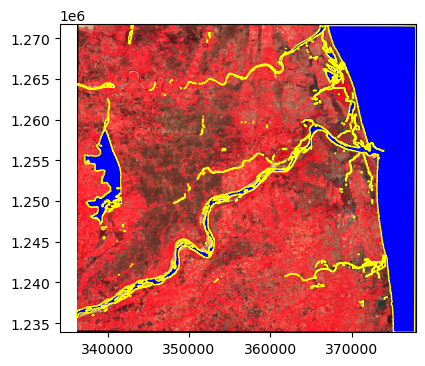

In [23]:
if scene_rio.crs != truth_vec_gpd.crs:
    print('crs transformation needed')
    truth_vec_gpd = truth_vec_gpd.to_crs(scene_rio.crs.to_dict())
## show the scene and the truth vector
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
imgShow(scene_rio.read([2,3,4]).transpose(1,2,0), 
            ax=ax, clip_percent=5, extent=scene_extent)
truth_vec_gpd.plot(ax=ax, color='blue',
                   edgecolor='yellow', linewidth=1) 


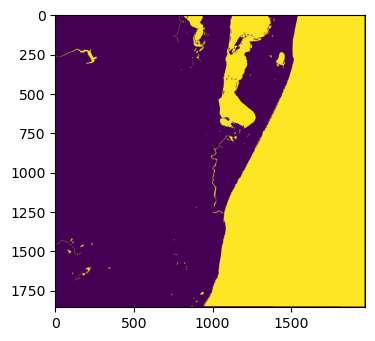

In [32]:
###  create a mask from the truth vector
def create_mask_from_vec(img_rio, vec_gpd):
    if vec_gpd.crs != img_rio.crs:
        vec_gpd = vec_gpd.to_crs(img_rio.crs.to_dict())
    shapes = [(geom, 1) for geom in vec_gpd.geometry if geom is not None and not geom.is_empty]

    mask_water = features.rasterize(
        shapes=shapes,
        out_shape=(img_rio.height, img_rio.width),
        transform=img_rio.transform,
        all_touched=False,
        default_value=1,
        fill=0,
        dtype=np.uint8)
    return mask_water

mask_water = create_mask_from_vec(img_rio = scene_rio, vec_gpd=truth_vec_gpd)
plt.figure(figsize=(4, 4))
plt.imshow(mask_water) 


In [25]:
## write the mask to a geotiff
path_truth_gpkg = paths_truth[id_dset]
path_truth_tif = path_truth_gpkg.replace('gpkg', 'tif')

def write_mask_to_geotiff(mask, scene_rio, path_save):
    mask_meta = scene_rio.meta.copy()
    mask_meta.update({
        'dtype': 'uint8',
        'count': 1,
        'compress': 'lzw',
        'nodata': 0
    })    
    with rio.open(path_save, 'w', **mask_meta) as dst:
        dst.write(mask, 1)
    print('mask written to', path_save)

write_mask_to_geotiff(mask = mask_water, scene_rio=scene_rio, path_save = path_truth_tif)


mask written to data/dset/truth/truth_tif/l8/l8_scene_19_truth_final.tif


In [29]:
## batch processing: convert the .gpkg vector to .tiff truth image.
for i, path_truth_vec in enumerate(paths_truth):
    truth_vec_gpd = gpd.read_file(path_truth_vec)
    scene_rio = rio.open(paths_scene[i])
    ### generate water mask
    if scene_rio.crs != truth_vec_gpd.crs:
        truth_vec_gpd = truth_vec_gpd.to_crs(scene_rio.crs.to_dict())
    mask_water = create_mask_from_vec(img_rio = scene_rio, 
                                        vec_gpd=truth_vec_gpd)
    ### write the water mask to a geotiff
    path_truth_img = path_truth_vec.replace('gpkg', 'tif')
    write_mask_to_geotiff(mask = mask_water, scene_rio=scene_rio, 
                                        path_save = path_truth_img)
    scene_rio.close()
    # break 


mask written to data/dset/truth/truth_tif/l5/l5_scene_01_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_02_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_03_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_04_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_05_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_06_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_07_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_08_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_09_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_10_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_11_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_12_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_scene_13_truth_final.tif
mask written to data/dset/truth/truth_tif/l5/l5_sce